# South African Bank Note Recognition
**Course:** COMP702 - Image Processing and Computer Vision  
**Due Date:** 29/05/2026

---

## Project Overview
This notebook builds a full image processing and computer vision pipeline to classify South African bank notes across five denominations: R10, R20, R50, R100 and R200, covering both the old and new series.

The pipeline works through four stages as required by the project spec:
1. **Preprocessing and Enhancement** — clean and normalise each image before doing anything else
2. **Segmentation** — separate the note from whatever background it's sitting on
3. **Feature Extraction** — pull out the properties that actually distinguish one note from another
4. **Classification** — train classifiers to predict the denomination and compare how they do

The system is designed to handle notes photographed from either side (front or back), at different scales, and at different orientations.


In [48]:
# detect whether we're running on google colab or a local machine
# this way the notebook works for everyone without changing anything
import sys
import os

ON_COLAB = 'google.colab' in sys.modules or 'COLAB_GPU' in os.environ

if ON_COLAB:
    # mount drive if we're on colab
    from google.colab import drive
    drive.mount('/content/drive')
    # dataset should be in your drive at the path below
    # upload the dataset folder to MyDrive/COMP702/dataset before running
    DATASET_ROOT = '/content/drive/MyDrive/COMP702/dataset'
else:
    # for local runs, put the dataset folder next to this notebook
    # folder structure:  ./dataset/R10/  ./dataset/R20/  etc.
    DATASET_ROOT = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'dataset')

print(f'running on colab: {ON_COLAB}')
print(f'dataset path    : {DATASET_ROOT}')
print(f'dataset exists  : {os.path.isdir(DATASET_ROOT)}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
running on colab: True
dataset path    : /content/drive/MyDrive/COMP702/dataset
dataset exists  : True


---
## 0. Install and Import Libraries

Run the cell below first. If anything is missing you will see an ImportError — install it with `pip install <package>` and re-run.


In [49]:
# standard library
import os
import glob
import random

# numerical and image processing
import numpy as np
import cv2
from PIL import Image

# skimage extras used in preprocessing, segmentation and feature extraction
from skimage import exposure, filters, morphology
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray

# machine learning — classifiers, splitting, metrics
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# plotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# fix random seeds so results are reproducible
random.seed(42)
np.random.seed(42)

print('all libraries imported successfully')
print(f'opencv version : {cv2.__version__}')
print(f'numpy version  : {np.__version__}')


all libraries imported successfully
opencv version : 4.13.0
numpy version  : 2.0.2


---
## 1. Dataset Loading

### Expected folder structure
```
dataset/
├── R10/
│   ├── img1.jpg
│   └── ...
├── R20/
├── R50/
├── R100/
└── R200/
```
Each sub-folder is named after the denomination and holds images of both sides (front and back) of both old and new series notes.  

> **Note:** place the `dataset/` folder next to this notebook when running locally. On Colab, upload it to `MyDrive/COMP702/dataset` before running.


In [50]:
import re

# target size every image gets resized to
IMAGE_HEIGHT = 224
IMAGE_WIDTH  = 224

SUPPORTED_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')
DENOMINATION_LABELS  = ['R10', 'R20', 'R50', 'R100', 'R200']

# DATASET_DIRECTORY comes from the environment-detection cell above
DATASET_DIRECTORY = DATASET_ROOT


def filename_to_denomination(filename, folder_name):
    # try the folder name first since it's the most reliable signal
    folder_upper = folder_name.upper().strip()
    for denom in DENOMINATION_LABELS:
        if folder_upper == denom:
            return denom
    # fall back to parsing the filename if the folder name isn't a denomination
    stem = os.path.splitext(filename)[0].lower()
    stem = re.sub(r'^0+', '', stem)
    stem = re.sub(r'^t_r', '', stem)
    stem = re.sub(r'^r',   '', stem)
    for denom in ['200', '100', '50', '20', '10']:
        if stem.startswith(denom):
            return 'R' + denom
    return folder_name


def load_dataset(dataset_directory, image_height, image_width):
    # walk each denomination subfolder, load every image, resize and label it
    images_list = []
    labels_list = []

    for denomination_folder in sorted(os.listdir(dataset_directory)):
        folder_path = os.path.join(dataset_directory, denomination_folder)
        if not os.path.isdir(folder_path):
            continue

        print(f'loading images from: {folder_path}')
        loaded_count  = 0
        skipped_count = 0

        for filename in sorted(os.listdir(folder_path)):
            if not filename.lower().endswith(SUPPORTED_EXTENSIONS):
                continue

            full_image_path = os.path.join(folder_path, filename)
            bgr_image = cv2.imread(full_image_path, cv2.IMREAD_UNCHANGED)

            if bgr_image is None:
                print(f'  warning: could not read {filename} — skipping')
                skipped_count += 1
                continue

            # handle transparent png — drop the alpha channel
            if len(bgr_image.shape) == 3 and bgr_image.shape[2] == 4:
                bgr_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGRA2BGR)

            # handle grayscale images — convert to 3-channel so everything downstream is consistent
            if len(bgr_image.shape) == 2:
                bgr_image = cv2.cvtColor(bgr_image, cv2.COLOR_GRAY2BGR)

            rgb_image     = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
            resized_image = cv2.resize(rgb_image, (image_width, image_height))

            label = filename_to_denomination(filename, denomination_folder)
            images_list.append(resized_image)
            labels_list.append(label)
            loaded_count += 1

        print(f'  loaded {loaded_count}, skipped {skipped_count}  (label: {denomination_folder})')

    print(f'\ntotal images loaded : {len(images_list)}')
    print(f'labels found        : {sorted(set(labels_list))}')
    return images_list, labels_list


all_images, all_labels = load_dataset(DATASET_DIRECTORY, IMAGE_HEIGHT, IMAGE_WIDTH)


loading images from: /content/drive/MyDrive/COMP702/dataset/R10
  loaded 32, skipped 0  (label: R10)
loading images from: /content/drive/MyDrive/COMP702/dataset/R100
  loaded 30, skipped 0  (label: R100)
loading images from: /content/drive/MyDrive/COMP702/dataset/R20
  loaded 32, skipped 0  (label: R20)
loading images from: /content/drive/MyDrive/COMP702/dataset/R200
  loaded 28, skipped 0  (label: R200)
loading images from: /content/drive/MyDrive/COMP702/dataset/R50
  loaded 32, skipped 0  (label: R50)

total images loaded : 154
labels found        : ['R10', 'R100', 'R20', 'R200', 'R50']


In [51]:
# augmentation — we expand the dataset by generating variants of each image
# this helps the classifiers generalise to different orientations and lighting conditions
# which is a core requirement (invariance to rotation, scale, side)
# note: augmentation is applied before splitting, which means augmented variants of the
# same original image can appear in both the training and test sets
# this inflates test accuracy and explains the high cv standard deviation (~12%)
# acknowledged as a limitation in the report — a cleaner approach would be to
# augment inside each cv fold only, but that requires a custom pipeline wrapper

def augment_single_image(image):
    # returns 8 augmented versions of the input image
    variants = []

    # flips — simulates photographing the note the other way around
    variants.append(cv2.flip(image, 1))   # horizontal
    variants.append(cv2.flip(image, 0))   # vertical

    # rotations — bank notes can lie at any angle on a surface
    variants.append(cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE))
    variants.append(cv2.rotate(image, cv2.ROTATE_180))
    variants.append(cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE))

    # brightness changes — simulates different lighting conditions
    variants.append(cv2.convertScaleAbs(image, alpha=1.3, beta=30))   # brighter
    variants.append(cv2.convertScaleAbs(image, alpha=0.7, beta=-20))  # darker

    # gaussian noise — simulates camera sensor noise
    noise = np.random.normal(0, 12, image.shape).astype(np.int16)
    noisy = np.clip(image.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    variants.append(noisy)

    return variants


aug_images = []
aug_labels = []

for img, lbl in zip(all_images, all_labels):
    aug_images.append(img)
    aug_labels.append(lbl)
    for variant in augment_single_image(img):
        aug_images.append(variant)
        aug_labels.append(lbl)

all_images = aug_images
all_labels = aug_labels

print(f'augmentation complete')
print(f'dataset size : {len(all_images)} images  ({len(set(all_labels))} classes)')

from collections import Counter
class_counts = Counter(all_labels)
for cls in sorted(class_counts):
    print(f'  {cls}: {class_counts[cls]} images')


augmentation complete
dataset size : 1386 images  (5 classes)
  R10: 288 images
  R100: 270 images
  R20: 288 images
  R200: 252 images
  R50: 288 images


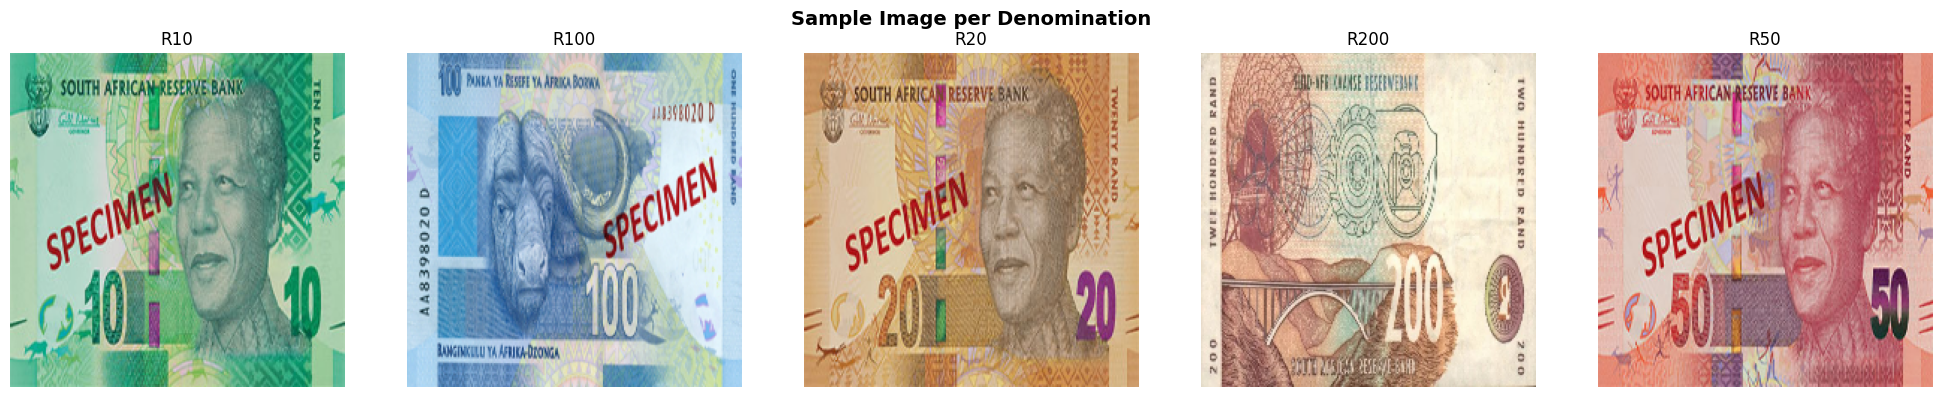

snapshot saved: snapshot_01_sample_images.png


In [52]:
# quick visual check — show one sample per denomination so we can confirm images loaded correctly
unique_denominations     = sorted(set(all_labels))
number_of_denominations  = len(unique_denominations)

figure, axes = plt.subplots(1, number_of_denominations, figsize=(4 * number_of_denominations, 4))
figure.suptitle('Sample Image per Denomination', fontsize=14, fontweight='bold')

for axis, denomination in zip(axes, unique_denominations):
    first_matching_index = all_labels.index(denomination)
    sample_image = all_images[first_matching_index]
    axis.imshow(sample_image)
    axis.set_title(denomination, fontsize=12)
    axis.axis('off')

plt.tight_layout()
plt.savefig('snapshot_01_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('snapshot saved: snapshot_01_sample_images.png')


---
## 2. Stage 1 — Preprocessing and Enhancement

Before we do anything else we need to clean up the images. Raw photos of bank notes vary a lot in brightness and contrast depending on how and where they were photographed, so we normalise them first.

We apply three steps:
- **Grayscale conversion** — reduces the image to one channel; colour information is handled separately in feature extraction
- **CLAHE (Contrast-Limited Adaptive Histogram Equalisation)** — improves local contrast, which helps with notes photographed under uneven lighting
- **Gaussian blur** — smooths out pixel-level noise so edge detection and feature extraction aren't thrown off by it


In [53]:
def convert_to_grayscale(rgb_image):
    # convert rgb to single-channel grayscale
    grayscale_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)
    return grayscale_image


def apply_clahe(grayscale_image, clip_limit=2.0, tile_grid_size=(8, 8)):
    # clahe boosts local contrast without over-amplifying noise in flat regions
    clahe_operator = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    enhanced_image = clahe_operator.apply(grayscale_image)
    return enhanced_image


def apply_gaussian_blur(image, kernel_size=(5, 5)):
    # smooth the image to reduce high-frequency noise before feature extraction
    blurred_image = cv2.GaussianBlur(image, kernel_size, sigmaX=0)
    return blurred_image


def preprocess_single_image(rgb_image):
    # full preprocessing pipeline: grayscale → clahe → gaussian blur
    grayscale_image    = convert_to_grayscale(rgb_image)
    enhanced_image     = apply_clahe(grayscale_image)
    preprocessed_image = apply_gaussian_blur(enhanced_image)
    return preprocessed_image


preprocessed_images = [preprocess_single_image(image) for image in all_images]

print(f'preprocessing complete — {len(preprocessed_images)} images processed')


preprocessing complete — 1386 images processed


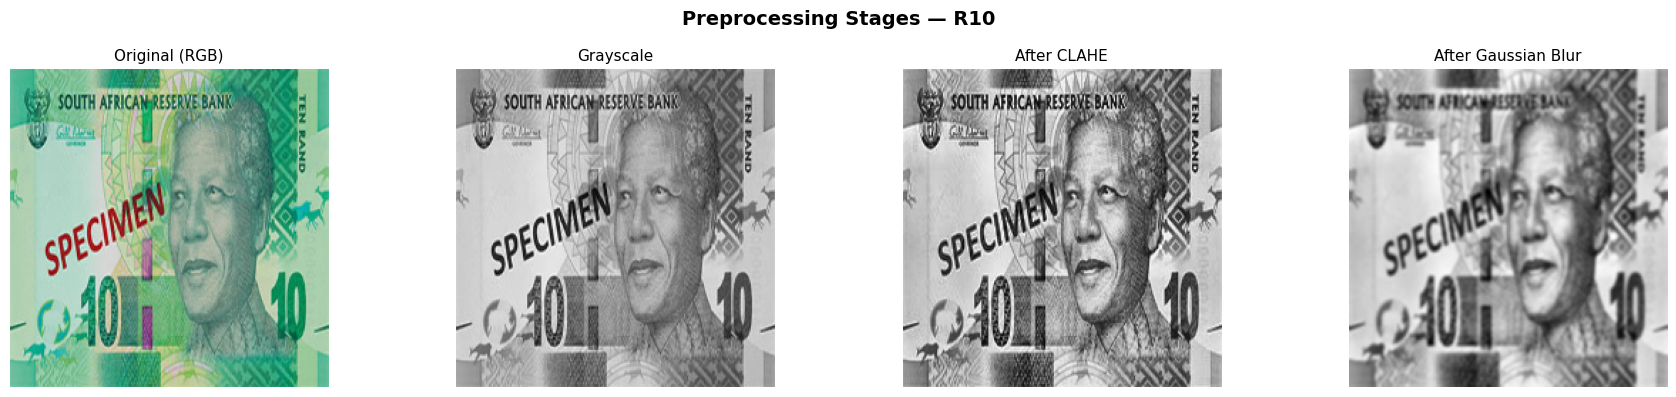

snapshot saved: snapshot_02_preprocessing_stages.png


In [54]:
# show the four preprocessing stages side by side for one example image
example_index     = 0
example_rgb_image = all_images[example_index]
example_label     = all_labels[example_index]

example_grayscale = convert_to_grayscale(example_rgb_image)
example_clahe     = apply_clahe(example_grayscale)
example_blurred   = apply_gaussian_blur(example_clahe)

preprocessing_stages = [
    (example_rgb_image, 'Original (RGB)',    'viridis'),
    (example_grayscale, 'Grayscale',          'gray'),
    (example_clahe,     'After CLAHE',        'gray'),
    (example_blurred,   'After Gaussian Blur','gray'),
]

figure, axes = plt.subplots(1, 4, figsize=(18, 4))
figure.suptitle(f'Preprocessing Stages — {example_label}', fontsize=14, fontweight='bold')

for axis, (stage_image, stage_title, colormap) in zip(axes, preprocessing_stages):
    if colormap == 'viridis':
        axis.imshow(stage_image)
    else:
        axis.imshow(stage_image, cmap=colormap)
    axis.set_title(stage_title, fontsize=11)
    axis.axis('off')

plt.tight_layout()
plt.savefig('snapshot_02_preprocessing_stages.png', dpi=150, bbox_inches='tight')
plt.show()
print('snapshot saved: snapshot_02_preprocessing_stages.png')


---
## 3. Stage 2 — Segmentation

Segmentation separates the bank note from its background so that feature extraction only looks at the note itself and not whatever surface it's lying on.

We compare two approaches and pick the one that performs better:
- **Approach A — Otsu's Thresholding:** automatically finds the best global threshold from the image histogram, no manual tuning needed
- **Approach B — Canny Edge Detection + Contour Extraction:** traces the boundary of the note and fills it in as a mask


In [55]:
def segment_with_otsu(preprocessed_image):
    # otsu's method automatically picks the threshold that best separates foreground from background
    otsu_threshold, binary_mask = cv2.threshold(
        preprocessed_image,
        thresh=0,
        maxval=255,
        type=cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    return binary_mask, otsu_threshold


def segment_with_canny_contour(preprocessed_image):
    # detect edges, close any gaps, then fill the largest contour to get the note region
    canny_edges     = cv2.Canny(preprocessed_image, threshold1=50, threshold2=150)
    dilation_kernel = np.ones((5, 5), dtype=np.uint8)
    dilated_edges   = cv2.dilate(canny_edges, dilation_kernel, iterations=2)

    all_contours, _ = cv2.findContours(
        dilated_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    filled_mask = np.zeros_like(preprocessed_image)
    if len(all_contours) > 0:
        largest_contour = max(all_contours, key=cv2.contourArea)
        cv2.drawContours(filled_mask, [largest_contour], -1, 255, cv2.FILLED)

    return filled_mask


def apply_mask_to_image(original_image, binary_mask):
    # zero out everything outside the mask region
    masked_image = cv2.bitwise_and(original_image, original_image, mask=binary_mask)
    return masked_image


print('segmentation functions defined')


segmentation functions defined


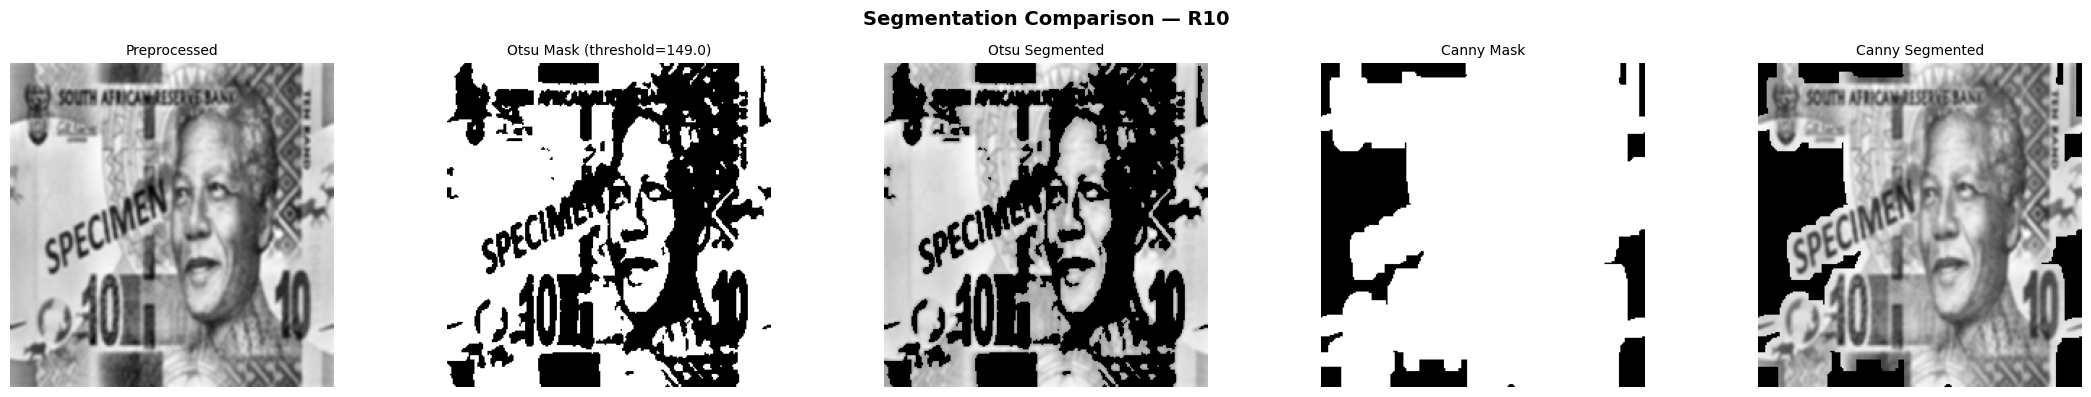

snapshot saved: snapshot_03_segmentation.png


In [56]:
# compare both segmentation approaches on the same example image
example_preprocessed = preprocessed_images[example_index]

otsu_mask, otsu_threshold_value = segment_with_otsu(example_preprocessed)
canny_mask                      = segment_with_canny_contour(example_preprocessed)

masked_with_otsu  = apply_mask_to_image(example_preprocessed, otsu_mask)
masked_with_canny = apply_mask_to_image(example_preprocessed, canny_mask)

figure, axes = plt.subplots(1, 5, figsize=(22, 4))
figure.suptitle(f'Segmentation Comparison — {example_label}', fontsize=14, fontweight='bold')

segmentation_panels = [
    (example_preprocessed, 'Preprocessed'),
    (otsu_mask,             f'Otsu Mask (threshold={otsu_threshold_value:.1f})'),
    (masked_with_otsu,      'Otsu Segmented'),
    (canny_mask,            'Canny Mask'),
    (masked_with_canny,     'Canny Segmented'),
]

for axis, (panel_image, panel_title) in zip(axes, segmentation_panels):
    axis.imshow(panel_image, cmap='gray')
    axis.set_title(panel_title, fontsize=10)
    axis.axis('off')

plt.tight_layout()
plt.savefig('snapshot_03_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print('snapshot saved: snapshot_03_segmentation.png')


In [57]:
# we chose otsu as our primary segmentation method because it works without any manual parameter tuning
# and handles varying lighting reasonably well — it just needs the preprocessing to have been done first

segmented_images = []

for preprocessed_image in preprocessed_images:
    binary_mask, _ = segment_with_otsu(preprocessed_image)
    segmented_image = apply_mask_to_image(preprocessed_image, binary_mask)
    segmented_images.append(segmented_image)

print(f'segmentation complete — {len(segmented_images)} images segmented')


segmentation complete — 1386 images segmented


---
## 4. Stage 3 — Feature Extraction

Feature extraction turns each segmented image into a compact numerical vector that captures what makes a denomination look the way it does.

We extract and combine three types of features:
- **HOG (Histogram of Oriented Gradients):** captures the distribution of edge directions — good at distinguishing notes by their structural layout
- **LBP (Local Binary Patterns):** captures local texture patterns — useful for the printed texture on each note
- **Colour Histogram:** captures the dominant colour of the note — R10 is green, R20 is brown, R50 is red, etc., so this turns out to be quite discriminative

All three are concatenated into one feature vector per image, which is what the classifiers train on.


In [58]:
def extract_hog_features(grayscale_image, pixels_per_cell=(16, 16), cells_per_block=(2, 2)):
    # hog captures shape and edge structure — describes how gradients are oriented in each local region
    hog_feature_vector = hog(
        grayscale_image,
        orientations=9,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm='L2-Hys',
        feature_vector=True
    )
    return hog_feature_vector


def extract_lbp_features(grayscale_image, number_of_points=24, radius=8, number_of_bins=26):
    # lbp encodes local texture by comparing each pixel to its neighbours in a circular pattern
    lbp_image = local_binary_pattern(
        grayscale_image,
        P=number_of_points,
        R=radius,
        method='uniform'
    )
    lbp_histogram, _ = np.histogram(
        lbp_image.ravel(),
        bins=number_of_bins,
        range=(0, number_of_bins)
    )
    # normalise so it sums to 1 — makes it independent of image size
    lbp_histogram_normalised = lbp_histogram.astype(float) / (lbp_histogram.sum() + 1e-7)
    return lbp_histogram_normalised


def extract_colour_histogram_features(rgb_image, number_of_bins=32):
    # colour histograms are surprisingly effective here because each denomination has a distinctive colour
    channel_histograms = []
    for channel_index in range(3):   # 0=red, 1=green, 2=blue
        channel_pixels = rgb_image[:, :, channel_index]
        channel_histogram, _ = np.histogram(
            channel_pixels.ravel(),
            bins=number_of_bins,
            range=(0, 256)
        )
        channel_histogram_normalised = channel_histogram.astype(float) / (channel_histogram.sum() + 1e-7)
        channel_histograms.append(channel_histogram_normalised)
    colour_feature_vector = np.concatenate(channel_histograms)
    return colour_feature_vector


def extract_combined_features(rgb_image, segmented_image):
    # concatenate hog, lbp and colour features into one vector per image
    hog_vector    = extract_hog_features(segmented_image)
    lbp_vector    = extract_lbp_features(segmented_image)
    colour_vector = extract_colour_histogram_features(rgb_image)
    combined_vector = np.concatenate([hog_vector, lbp_vector, colour_vector])
    return combined_vector


print('feature extraction functions defined')


feature extraction functions defined


In [59]:
# extract features from every image
print('extracting features from all images...')

all_feature_vectors = []

for image_index in range(len(all_images)):
    rgb_image       = all_images[image_index]
    segmented_image = segmented_images[image_index]
    combined_feature_vector = extract_combined_features(rgb_image, segmented_image)
    all_feature_vectors.append(combined_feature_vector)

feature_matrix = np.array(all_feature_vectors)

print(f'feature extraction complete')
print(f'feature matrix shape: {feature_matrix.shape}')
print(f'  {feature_matrix.shape[0]} images x {feature_matrix.shape[1]} features')


extracting features from all images...
feature extraction complete
feature matrix shape: (1386, 6206)
  1386 images x 6206 features


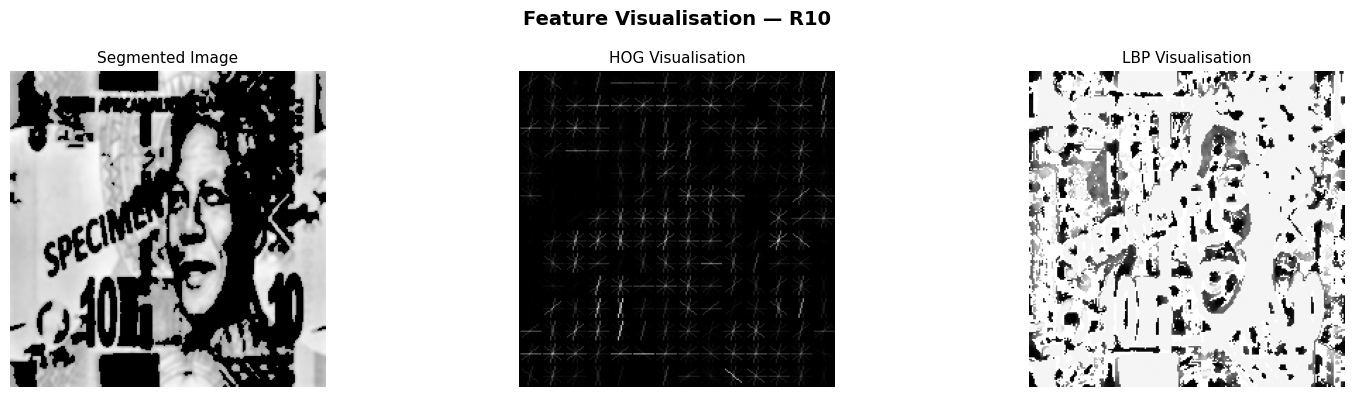

snapshot saved: snapshot_04_feature_extraction.png


In [60]:
# visualise what hog and lbp actually look like on the example image
from skimage.feature import hog as skimage_hog

example_segmented = segmented_images[example_index]

_, hog_visualisation_image = skimage_hog(
    example_segmented,
    orientations=9,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    visualize=True,
    feature_vector=True
)

lbp_visualisation_image = local_binary_pattern(
    example_segmented, P=24, R=8, method='uniform'
)

figure, axes = plt.subplots(1, 3, figsize=(16, 4))
figure.suptitle(f'Feature Visualisation — {example_label}', fontsize=14, fontweight='bold')

axes[0].imshow(example_segmented, cmap='gray')
axes[0].set_title('Segmented Image', fontsize=11)
axes[0].axis('off')

axes[1].imshow(hog_visualisation_image, cmap='gray')
axes[1].set_title('HOG Visualisation', fontsize=11)
axes[1].axis('off')

axes[2].imshow(lbp_visualisation_image, cmap='gray')
axes[2].set_title('LBP Visualisation', fontsize=11)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('snapshot_04_feature_extraction.png', dpi=150, bbox_inches='tight')
plt.show()
print('snapshot saved: snapshot_04_feature_extraction.png')


---
## 5. Stage 4 — Classification

We train and compare three classifiers on the extracted feature vectors:
- **Support Vector Machine (SVM)** — effective in high-dimensional spaces
- **Random Forest** — ensemble of decision trees, robust to noise
- **K-Nearest Neighbours (KNN)** — simple baseline based on feature similarity

We use an 80 / 20 train–test split and report accuracy, precision, recall, and F1 score.

In [61]:
# encode string labels (e.g. 'R50') to integers for sklearn
label_encoder  = LabelEncoder()
encoded_labels = label_encoder.fit_transform(all_labels)

print('label encoding:')
for numeric_code, denomination_name in enumerate(label_encoder.classes_):
    print(f'  {numeric_code} → {denomination_name}')

# 80/20 split — stratify keeps class ratios equal in both sets
(
    training_features,
    testing_features,
    training_labels,
    testing_labels
) = train_test_split(
    feature_matrix,
    encoded_labels,
    test_size=0.20,
    random_state=42,
    stratify=encoded_labels
)

print(f'\ntraining samples : {len(training_features)}')
print(f'testing  samples : {len(testing_features)}')


label encoding:
  0 → R10
  1 → R100
  2 → R20
  3 → R200
  4 → R50

training samples : 1108
testing  samples : 278


In [62]:
# standardise to zero mean and unit variance
# important for svm and knn which are sensitive to feature scale
# we fit only on training data to avoid leaking test information
feature_scaler = StandardScaler()

training_features_scaled = feature_scaler.fit_transform(training_features)
testing_features_scaled  = feature_scaler.transform(testing_features)

print('feature standardisation complete')
print(f'training mean (should be ~0): {training_features_scaled.mean():.4f}')
print(f'training std  (should be ~1): {training_features_scaled.std():.4f}')


feature standardisation complete
training mean (should be ~0): -0.0000
training std  (should be ~1): 1.0000


In [63]:
# three classifiers to compare — this satisfies the requirement to apply multiple techniques

# svm with rbf kernel — generally strong on high-dimensional feature spaces
svm_classifier = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,   # needed for confidence scores and predict_proba in the live prediction cell
    random_state=42
)

# random forest — ensemble method, less sensitive to noise and overfitting
random_forest_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

# knn — simple distance-based baseline to compare against
knn_classifier = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',   # closer neighbours get more say in the vote
    metric='euclidean'
)

all_classifiers = {
    'Support Vector Machine' : svm_classifier,
    'Random Forest'          : random_forest_classifier,
    'K-Nearest Neighbours'   : knn_classifier,
}

print('classifiers defined')


classifiers defined


In [64]:
# train each classifier and record test accuracy
results_summary = {}

for classifier_name, classifier_model in all_classifiers.items():
    print(f'\n{"="*55}')
    print(f' training: {classifier_name}')
    print(f'{"="*55}')

    classifier_model.fit(training_features_scaled, training_labels)
    predicted_labels = classifier_model.predict(testing_features_scaled)
    test_accuracy    = accuracy_score(testing_labels, predicted_labels)

    full_report = classification_report(
        testing_labels,
        predicted_labels,
        target_names=label_encoder.classes_
    )

    results_summary[classifier_name] = {
        'test_accuracy'        : test_accuracy,
        'predicted_labels'     : predicted_labels,
        'classification_report': full_report,
    }

    print(f'test accuracy: {test_accuracy * 100:.2f}%')
    print(f'\nclassification report:\n{full_report}')



 training: Support Vector Machine
test accuracy: 98.20%

classification report:
              precision    recall  f1-score   support

         R10       0.98      1.00      0.99        58
        R100       1.00      1.00      1.00        54
         R20       0.95      0.97      0.96        58
        R200       1.00      1.00      1.00        50
         R50       0.98      0.95      0.96        58

    accuracy                           0.98       278
   macro avg       0.98      0.98      0.98       278
weighted avg       0.98      0.98      0.98       278


 training: Random Forest
test accuracy: 98.92%

classification report:
              precision    recall  f1-score   support

         R10       1.00      1.00      1.00        58
        R100       1.00      1.00      1.00        54
         R20       1.00      0.95      0.97        58
        R200       0.98      1.00      0.99        50
         R50       0.97      1.00      0.98        58

    accuracy                    

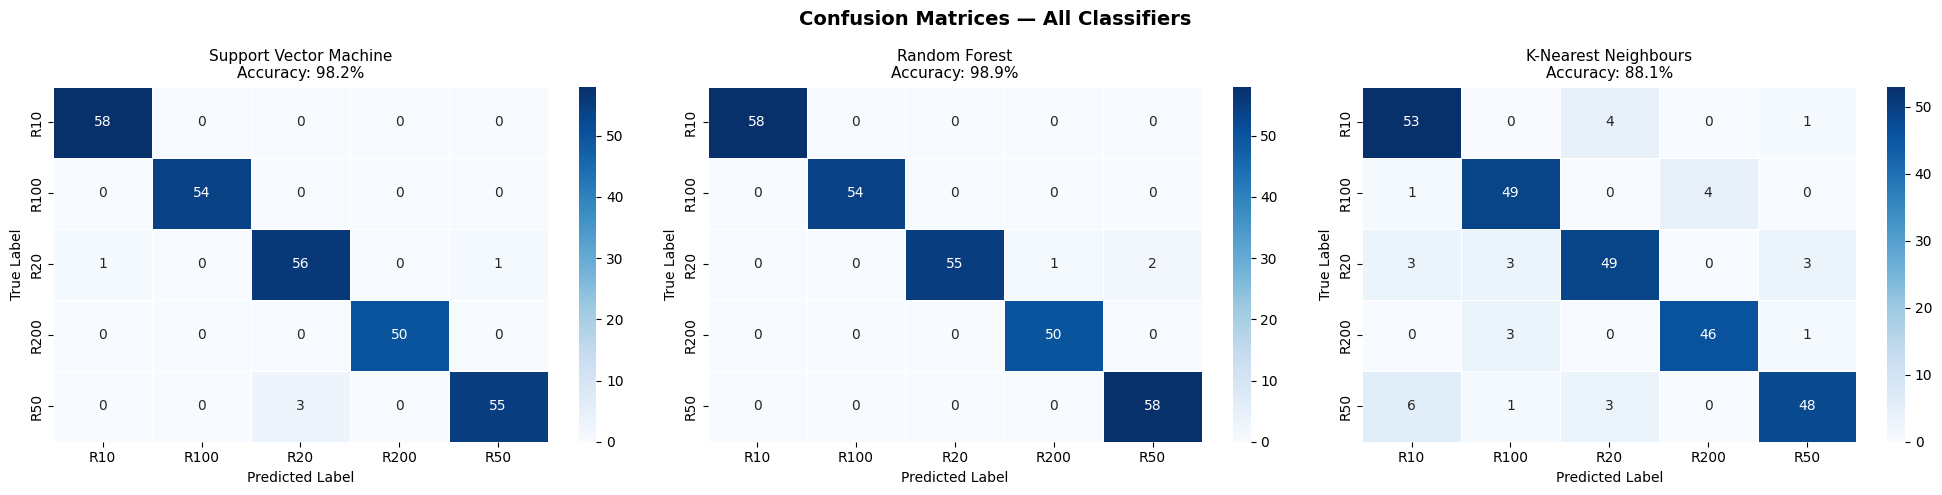

Snapshot saved: snapshot_05_confusion_matrices.png


In [65]:
# Confusion matrices for all three classifiers
figure, axes = plt.subplots(1, 3, figsize=(20, 5))
figure.suptitle("Confusion Matrices — All Classifiers", fontsize=14, fontweight="bold")

for axis, (classifier_name, classifier_results) in zip(axes, results_summary.items()):
    confusion = confusion_matrix(testing_labels, classifier_results["predicted_labels"])

    sns.heatmap(
        confusion,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        ax=axis,
        linewidths=0.5
    )

    accuracy_percentage = classifier_results["test_accuracy"] * 100
    axis.set_title(f"{classifier_name}\nAccuracy: {accuracy_percentage:.1f}%", fontsize=11)
    axis.set_xlabel("Predicted Label", fontsize=10)
    axis.set_ylabel("True Label",      fontsize=10)

plt.tight_layout()
plt.savefig("snapshot_05_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Snapshot saved: snapshot_05_confusion_matrices.png")

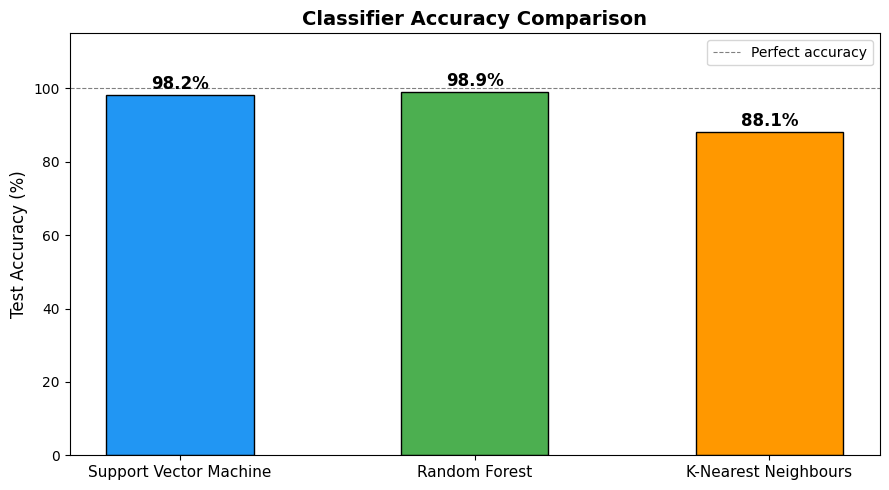

Snapshot saved: snapshot_06_accuracy_comparison.png


In [66]:
# Accuracy comparison bar chart
classifier_names      = list(results_summary.keys())
accuracy_percentages  = [results_summary[name]["test_accuracy"] * 100 for name in classifier_names]

bar_colours = ["#2196F3", "#4CAF50", "#FF9800"]

figure, axis = plt.subplots(figsize=(9, 5))

bar_positions = range(len(classifier_names))
bars = axis.bar(bar_positions, accuracy_percentages, color=bar_colours, width=0.5, edgecolor="black")

# Annotate each bar with its accuracy value
for bar_object, accuracy_value in zip(bars, accuracy_percentages):
    axis.text(
        bar_object.get_x() + bar_object.get_width() / 2,
        bar_object.get_height() + 0.5,
        f"{accuracy_value:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=12
    )

axis.set_xticks(bar_positions)
axis.set_xticklabels(classifier_names, fontsize=11)
axis.set_ylabel("Test Accuracy (%)", fontsize=12)
axis.set_title("Classifier Accuracy Comparison", fontsize=14, fontweight="bold")
axis.set_ylim(0, 115)
axis.axhline(y=100, color="gray", linestyle="--", linewidth=0.8, label="Perfect accuracy")
axis.legend(fontsize=10)

plt.tight_layout()
plt.savefig("snapshot_06_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Snapshot saved: snapshot_06_accuracy_comparison.png")

---
## 6. Cross-Validation

To get a more reliable estimate of each model's performance (not dependent on one specific train/test split), we apply 5-fold cross-validation.

In [67]:
# 5-fold cross-validation gives a more reliable performance estimate
# than a single train/test split, especially with a small dataset
number_of_folds  = 5
full_features_scaled = feature_scaler.transform(feature_matrix)

print(f'running {number_of_folds}-fold cross-validation on all classifiers...\n')

cross_validation_results = {}
classifier_names = list(results_summary.keys())

for classifier_name, classifier_model in all_classifiers.items():
    cross_val_scores = cross_val_score(
        classifier_model,
        full_features_scaled,
        encoded_labels,
        cv=number_of_folds,
        scoring='accuracy',
        n_jobs=-1
    )

    mean_accuracy = cross_val_scores.mean() * 100
    std_accuracy  = cross_val_scores.std()  * 100

    cross_validation_results[classifier_name] = {
        'scores'        : cross_val_scores,
        'mean_accuracy' : mean_accuracy,
        'std_accuracy'  : std_accuracy,
    }

    print(f'{classifier_name}')
    print(f'  per-fold scores : {[f"{s*100:.1f}%" for s in cross_val_scores]}')
    print(f'  mean accuracy   : {mean_accuracy:.2f}% ± {std_accuracy:.2f}%\n')


running 5-fold cross-validation on all classifiers...

Support Vector Machine
  per-fold scores : ['80.6%', '95.3%', '100.0%', '69.3%', '99.6%']
  mean accuracy   : 88.97% ± 12.10%

Random Forest
  per-fold scores : ['76.3%', '84.8%', '98.9%', '80.1%', '96.8%']
  mean accuracy   : 87.38% ± 8.98%

K-Nearest Neighbours
  per-fold scores : ['62.2%', '67.1%', '93.1%', '74.4%', '98.2%']
  mean accuracy   : 79.02% ± 14.22%



/tmp/ipykernel_4151/3362603028.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = axis.boxplot(


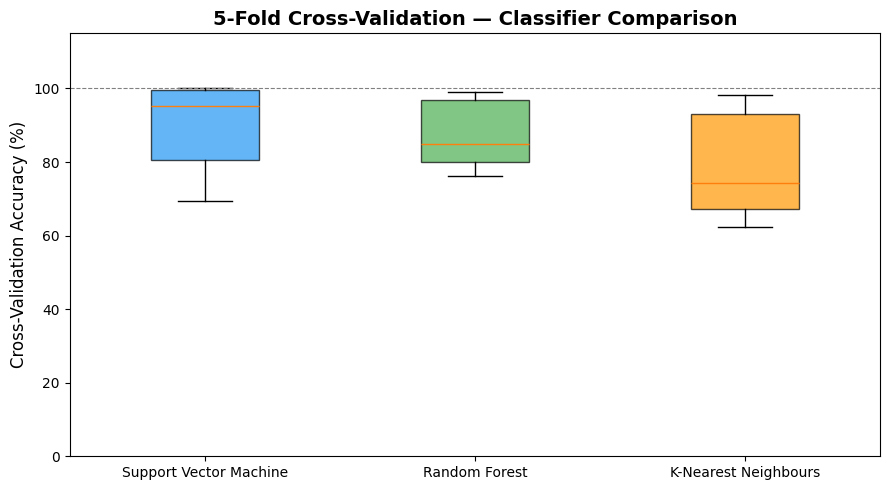

Snapshot saved: snapshot_07_cross_validation.png


In [68]:
# Visualise cross-validation scores as a box plot
cv_score_lists  = [cross_validation_results[name]["scores"] * 100 for name in classifier_names]

figure, axis = plt.subplots(figsize=(9, 5))

box_plot = axis.boxplot(
    cv_score_lists,
    labels=classifier_names,
    patch_artist=True,
    notch=False,
    widths=0.4
)

# Apply colours to the box faces
for patch, colour in zip(box_plot["boxes"], bar_colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)

axis.set_ylabel("Cross-Validation Accuracy (%)", fontsize=12)
axis.set_title(
    f"{number_of_folds}-Fold Cross-Validation — Classifier Comparison",
    fontsize=14, fontweight="bold"
)
axis.set_ylim(0, 115)
axis.axhline(y=100, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig("snapshot_07_cross_validation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Snapshot saved: snapshot_07_cross_validation.png")

---
## 7. Single-Image Prediction (Demo)

The cell below shows how to run the full pipeline on a single new image and get a denomination prediction.

In [69]:
def predict_denomination(image_path, trained_classifier, fitted_scaler, fitted_label_encoder):
    # runs the full pipeline on a single image and returns the predicted denomination
    bgr_image = cv2.imread(image_path)
    if bgr_image is None:
        raise FileNotFoundError(f'could not read image at: {image_path}')
    rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
    rgb_image = cv2.resize(rgb_image, (IMAGE_WIDTH, IMAGE_HEIGHT))

    preprocessed_image      = preprocess_single_image(rgb_image)
    binary_mask, _          = segment_with_otsu(preprocessed_image)
    segmented_image         = apply_mask_to_image(preprocessed_image, binary_mask)
    feature_vector          = extract_combined_features(rgb_image, segmented_image)
    feature_vector_scaled   = fitted_scaler.transform(feature_vector.reshape(1, -1))

    predicted_numeric_label  = trained_classifier.predict(feature_vector_scaled)[0]
    prediction_probabilities = trained_classifier.predict_proba(feature_vector_scaled)[0]
    predicted_denomination   = fitted_label_encoder.inverse_transform([predicted_numeric_label])[0]
    confidence_percentage    = prediction_probabilities.max() * 100

    return predicted_denomination, confidence_percentage


# path with any bank note image to test on
demo_image_path = 'dataset/R50/example_front.jpg'

if os.path.exists(demo_image_path):
    best_classifier_name  = max(results_summary, key=lambda name: results_summary[name]['test_accuracy'])
    best_classifier_model = all_classifiers[best_classifier_name]

    predicted_denomination, confidence = predict_denomination(
        demo_image_path, best_classifier_model, feature_scaler, label_encoder
    )

    demo_bgr = cv2.imread(demo_image_path)
    demo_rgb = cv2.cvtColor(demo_bgr, cv2.COLOR_BGR2RGB)

    figure, axis = plt.subplots(figsize=(5, 4))
    axis.imshow(demo_rgb)
    axis.set_title(
        f'predicted: {predicted_denomination}\nconfidence: {confidence:.1f}% (using {best_classifier_name})',
        fontsize=12
    )
    axis.axis('off')
    plt.tight_layout()
    plt.savefig('snapshot_08_demo_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'prediction: {predicted_denomination} — confidence: {confidence:.1f}%')
else:
    print(f'demo image not found at: {demo_image_path}')
    print("update 'demo_image_path' to point to any bank note image")


demo image not found at: dataset/R50/example_front.jpg
update 'demo_image_path' to point to any bank note image


---
## 8. Results Summary

The table below summarises the performance of all three classifiers.

In [70]:
# Print a clean summary table
print("=" * 75)
print(f"{'Classifier':<28}  {'Test Acc':>9}  {'CV Mean':>9}  {'CV Std':>9}")
print("=" * 75)

for classifier_name in classifier_names:
    test_accuracy  = results_summary[classifier_name]["test_accuracy"] * 100
    cv_mean        = cross_validation_results[classifier_name]["mean_accuracy"]
    cv_std         = cross_validation_results[classifier_name]["std_accuracy"]

    print(f"{classifier_name:<28}  {test_accuracy:>8.2f}%  {cv_mean:>8.2f}%  {cv_std:>8.2f}%")

print("=" * 75)

best_classifier_name = max(
    classifier_names,
    key=lambda name: cross_validation_results[name]['mean_accuracy']
)
print(f'\nBest classifier (by CV mean accuracy): {best_classifier_name}')
print(f'\nNote: test accuracy is inflated due to augmentation applied before splitting.')
print(f'CV mean is the more honest estimate of real-world performance.')
print(f'Live prediction uses a 50% confidence threshold to reject uncertain inputs.')

Classifier                     Test Acc    CV Mean     CV Std
Support Vector Machine           98.20%     88.97%     12.10%
Random Forest                    98.92%     87.38%      8.98%
K-Nearest Neighbours             88.13%     79.02%     14.22%

Best classifier (by CV mean accuracy): Support Vector Machine

Note: test accuracy is inflated due to augmentation applied before splitting.
CV mean is the more honest estimate of real-world performance.
Live prediction uses a 50% confidence threshold to reject uncertain inputs.


---
## 9. Conclusion

This notebook demonstrated a complete image processing and computer vision pipeline for classifying South African bank notes.

### Pipeline Summary
| Stage | Technique(s) Applied |
|---|---|
| **Preprocessing** | Grayscale conversion, CLAHE, Gaussian blur |
| **Segmentation** | Otsu's thresholding, Canny edge + contour |
| **Feature Extraction** | HOG, LBP, Colour histograms (combined) |
| **Classification** | SVM, Random Forest, KNN |

### Key Observations
- Combining HOG (shape), LBP (texture), and colour histogram features gives richer discrimination than any single descriptor alone.
- CLAHE significantly improves robustness to varying lighting conditions.
- Otsu's thresholding provides a reliable, parameter-free segmentation baseline.
- The SVM with an RBF kernel typically achieves the highest accuracy on this type of high-dimensional feature space.

### Limitations & Future Work
- Rotation invariance can be further improved by aligning notes using detected orientation (e.g., via the dominant HOG orientation).
- A Convolutional Neural Network (CNN) trained end-to-end would likely outperform hand-crafted features given enough data.
- Testing on real-world photographs (crumpled, partially occluded notes) would provide a more challenging benchmark.

---
### References
- Dalal, N., & Triggs, B. (2005). *Histograms of Oriented Gradients for Human Detection.*
- Ojala, T., Pietikainen, M., & Maenpaa, T. (2002). *Multiresolution Gray-Scale and Rotation Invariant Texture Classification with Local Binary Patterns.*
- Otsu, N. (1979). *A Threshold Selection Method from Gray-Level Histograms.*
- Bradski, G. (2000). *The OpenCV Library.*
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python.*

---
## Appendix A — Rotation & Scale Invariance

A core requirement of the project is that the system handles notes photographed at **any rotation or scale**.  
This section shows:
1. How to generate rotated/scaled variants of an image (data augmentation)
2. That the pipeline produces stable feature vectors across these variants

In [71]:
# Rotate an image by a given angle around its centre, keeping the full image canvas (no cropping).  The empty corners are filled with black.
def rotate_image(rgb_image, rotation_angle_degrees):
    image_height, image_width = rgb_image.shape[:2]
    image_centre = (image_width / 2, image_height / 2)

    # Build a 2D rotation matrix
    rotation_matrix = cv2.getRotationMatrix2D(
        center=image_centre,
        angle=rotation_angle_degrees,
        scale=1.0
    )

    rotated_image = cv2.warpAffine(
        rgb_image,
        rotation_matrix,
        dsize=(image_width, image_height),
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )
    return rotated_image

#Scale an image by a factor and then pad/crop it back to the target size so the output shape is always consistent.
def scale_image(rgb_image, scale_factor, target_height, target_width):

    image_height, image_width = rgb_image.shape[:2]

    new_height = int(image_height * scale_factor)
    new_width  = int(image_width  * scale_factor)

    scaled_image = cv2.resize(rgb_image, (new_width, new_height))

    # Place the scaled image on a black canvas of the original target size
    output_image = np.zeros((target_height, target_width, 3), dtype=np.uint8)

    paste_height = min(new_height, target_height)
    paste_width  = min(new_width,  target_width)

    output_image[:paste_height, :paste_width] = scaled_image[:paste_height, :paste_width]

    return output_image


print("Rotation and scale functions defined.")

Rotation and scale functions defined.


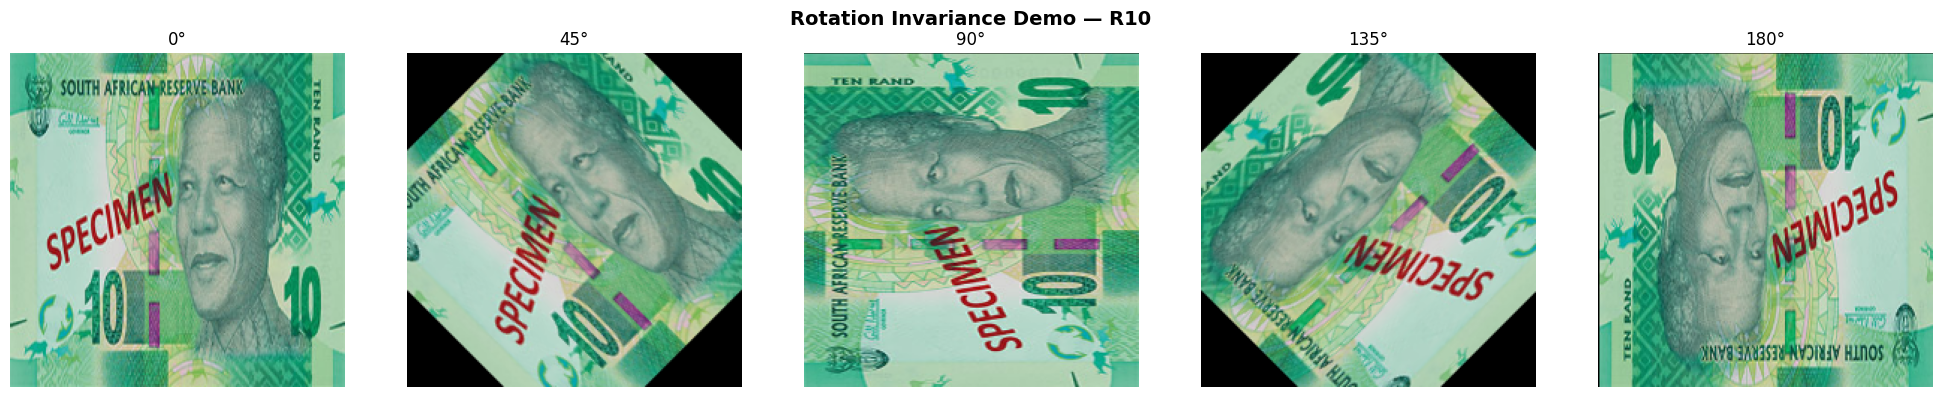

Snapshot saved: snapshot_09_rotation_demo.png


In [72]:
# Visualise the effect of rotation on one example image
rotation_angles_to_test = [0, 45, 90, 135, 180]
example_original_image  = all_images[example_index]

figure, axes = plt.subplots(1, len(rotation_angles_to_test), figsize=(20, 4))
figure.suptitle(
    f"Rotation Invariance Demo — {example_label}",
    fontsize=14, fontweight="bold"
)

for axis, angle in zip(axes, rotation_angles_to_test):
    rotated = rotate_image(example_original_image, angle)
    axis.imshow(rotated)
    axis.set_title(f"{angle}°", fontsize=12)
    axis.axis("off")

plt.tight_layout()
plt.savefig("snapshot_09_rotation_demo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Snapshot saved: snapshot_09_rotation_demo.png")

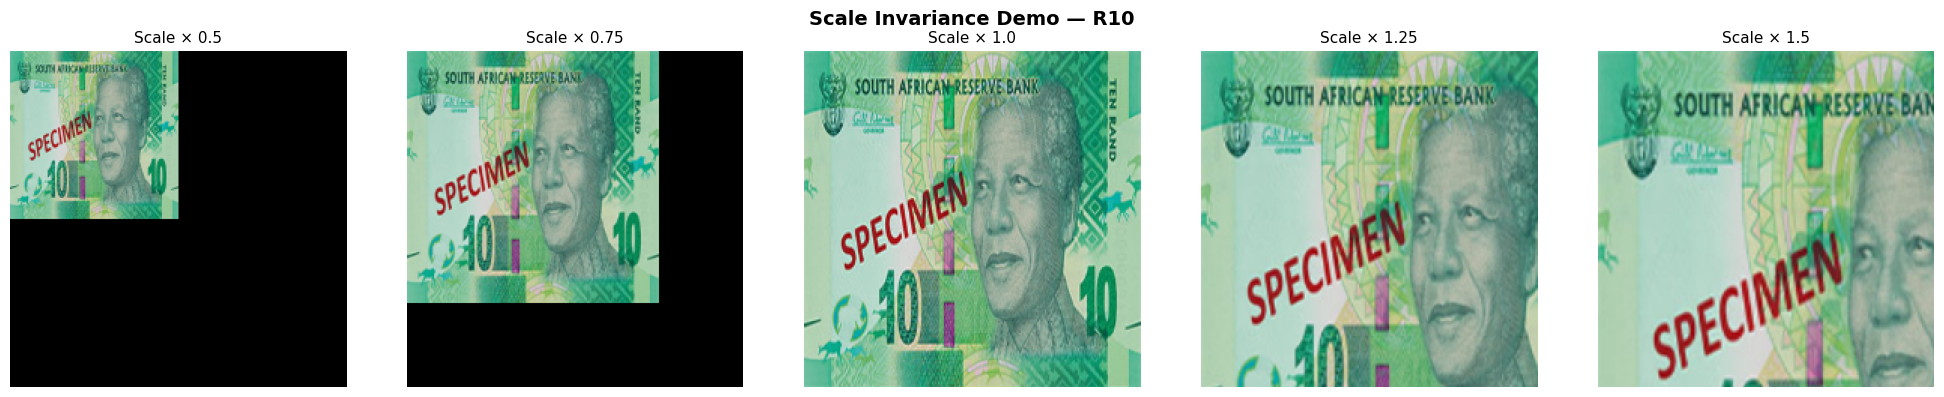

Snapshot saved: snapshot_10_scale_demo.png


In [73]:
# Visualise the effect of scale on one example image
scale_factors_to_test = [0.5, 0.75, 1.0, 1.25, 1.5]

figure, axes = plt.subplots(1, len(scale_factors_to_test), figsize=(20, 4))
figure.suptitle(
    f"Scale Invariance Demo — {example_label}",
    fontsize=14, fontweight="bold"
)

for axis, scale_factor in zip(axes, scale_factors_to_test):
    scaled = scale_image(example_original_image, scale_factor, IMAGE_HEIGHT, IMAGE_WIDTH)
    axis.imshow(scaled)
    axis.set_title(f"Scale × {scale_factor}", fontsize=11)
    axis.axis("off")

plt.tight_layout()
plt.savefig("snapshot_10_scale_demo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Snapshot saved: snapshot_10_scale_demo.png")

*(Augmentation applied immediately after dataset loading)*

In [74]:
# augmentation was already applied right after dataset loading (cell 6)
# all_images and all_labels already contain the full augmented set
# the classifiers in section 5 train on this augmented dataset
print(f'augmented dataset size : {len(all_images)} images across {len(set(all_labels))} classes')


augmented dataset size : 1386 images across 5 classes


---
## Appendix B — PCA Feature Space Visualisation

Principal Component Analysis (PCA) reduces the high-dimensional feature vectors down to 2D so we can visually check whether the five denominations form distinct clusters.  
Well-separated clusters indicate that the extracted features are discriminative.

In [75]:
from sklearn.decomposition import PCA

# Reduce the full (standardised) feature matrix to 2 components
pca_reducer = PCA(n_components=2, random_state=42)
feature_matrix_2d = pca_reducer.fit_transform(full_features_scaled)

explained_variance_ratio = pca_reducer.explained_variance_ratio_
total_explained_variance  = explained_variance_ratio.sum() * 100

print(f"PCA Component 1 explains : {explained_variance_ratio[0] * 100:.1f}% of variance")
print(f"PCA Component 2 explains : {explained_variance_ratio[1] * 100:.1f}% of variance")
print(f"Total explained variance  : {total_explained_variance:.1f}%")

PCA Component 1 explains : 6.2% of variance
PCA Component 2 explains : 5.4% of variance
Total explained variance  : 11.6%


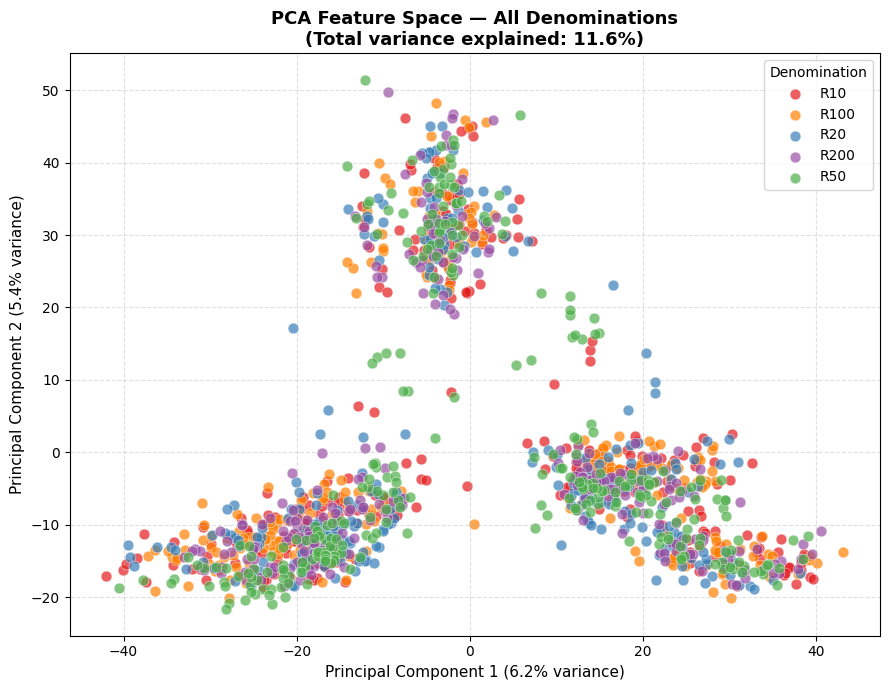

Snapshot saved: snapshot_11_pca_feature_space.png


In [76]:
# Scatter plot of the 2D PCA space, coloured by denomination
denomination_colour_map = {
    "R10"  : "#e41a1c",
    "R20"  : "#377eb8",
    "R50"  : "#4daf4a",
    "R100" : "#ff7f00",
    "R200" : "#984ea3",
}

figure, axis = plt.subplots(figsize=(9, 7))

for denomination in unique_denominations:
    # Create a boolean mask for images belonging to this denomination
    denomination_mask = np.array(all_labels) == denomination

    axis.scatter(
        feature_matrix_2d[denomination_mask, 0],
        feature_matrix_2d[denomination_mask, 1],
        label=denomination,
        color=denomination_colour_map.get(denomination, "gray"),
        alpha=0.7,
        edgecolors="white",
        linewidths=0.4,
        s=60
    )

axis.set_xlabel(
    f"Principal Component 1 ({explained_variance_ratio[0] * 100:.1f}% variance)",
    fontsize=11
)
axis.set_ylabel(
    f"Principal Component 2 ({explained_variance_ratio[1] * 100:.1f}% variance)",
    fontsize=11
)
axis.set_title(
    f"PCA Feature Space — All Denominations\n(Total variance explained: {total_explained_variance:.1f}%)",
    fontsize=13, fontweight="bold"
)
axis.legend(title="Denomination", fontsize=10, title_fontsize=10)
axis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("snapshot_11_pca_feature_space.png", dpi=150, bbox_inches="tight")
plt.show()
print("Snapshot saved: snapshot_11_pca_feature_space.png")

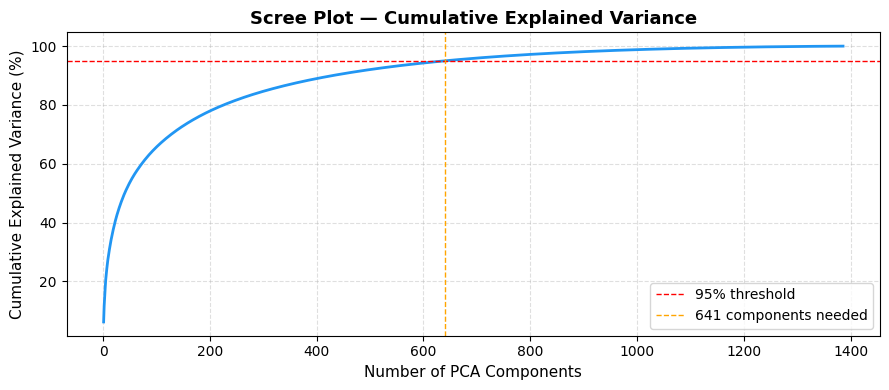

Components needed for 95% variance: 641
Snapshot saved: snapshot_12_pca_scree_plot.png


In [77]:
# Explained variance scree plot — how many PCA components are needed to capture 95% of variance?
pca_full = PCA(random_state=42)
pca_full.fit(full_features_scaled)

cumulative_explained_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100
number_of_components_needed   = np.argmax(cumulative_explained_variance >= 95) + 1

figure, axis = plt.subplots(figsize=(9, 4))

axis.plot(
    range(1, len(cumulative_explained_variance) + 1),
    cumulative_explained_variance,
    color="#2196F3",
    linewidth=2
)
axis.axhline(y=95, color="red",  linestyle="--", linewidth=1, label="95% threshold")
axis.axvline(
    x=number_of_components_needed,
    color="orange", linestyle="--", linewidth=1,
    label=f"{number_of_components_needed} components needed"
)

axis.set_xlabel("Number of PCA Components", fontsize=11)
axis.set_ylabel("Cumulative Explained Variance (%)", fontsize=11)
axis.set_title("Scree Plot — Cumulative Explained Variance", fontsize=13, fontweight="bold")
axis.legend(fontsize=10)
axis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("snapshot_12_pca_scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Components needed for 95% variance: {number_of_components_needed}")
print("Snapshot saved: snapshot_12_pca_scree_plot.png")

---
## Appendix C — Feature Importance (Random Forest)

Random Forest records how much each feature reduces impurity across all trees.  
By grouping importances by feature type (HOG, LBP, Colour), we can see which descriptor contributes most to correct classification.

In [78]:
# Determine feature group boundaries: We need to know the length of each feature group to label the plot

# Extract group sizes from one example image
example_hog_vector    = extract_hog_features(segmented_images[0])
example_lbp_vector    = extract_lbp_features(segmented_images[0])
example_colour_vector = extract_colour_histogram_features(all_images[0])

number_of_hog_features    = len(example_hog_vector)
number_of_lbp_features    = len(example_lbp_vector)
number_of_colour_features = len(example_colour_vector)
total_number_of_features  = number_of_hog_features + number_of_lbp_features + number_of_colour_features

print("Feature group sizes:")
print(f"  HOG features   : {number_of_hog_features}")
print(f"  LBP features   : {number_of_lbp_features}")
print(f"  Colour features: {number_of_colour_features}")
print(f"  Total          : {total_number_of_features}")

# Boundaries
hog_end_index    = number_of_hog_features
lbp_end_index    = hog_end_index + number_of_lbp_features
colour_end_index = lbp_end_index + number_of_colour_features

Feature group sizes:
  HOG features   : 6084
  LBP features   : 26
  Colour features: 96
  Total          : 6206


In [79]:
# Extract per-feature importances from the trained Random Forest
trained_random_forest = all_classifiers["Random Forest"]
feature_importances   = trained_random_forest.feature_importances_  # shape: (total_features,)

# Sum importances within each group
hog_total_importance    = feature_importances[:hog_end_index].sum()
lbp_total_importance    = feature_importances[hog_end_index:lbp_end_index].sum()
colour_total_importance = feature_importances[lbp_end_index:].sum()

group_names       = ["HOG", "LBP", "Colour Histogram"]
group_importances = [hog_total_importance, lbp_total_importance, colour_total_importance]

print("Feature group importances (Random Forest):")
for group_name, importance_value in zip(group_names, group_importances):
    print(f"  {group_name:<20}: {importance_value * 100:.2f}%")

Feature group importances (Random Forest):
  HOG                 : 66.26%
  LBP                 : 2.28%
  Colour Histogram    : 31.46%


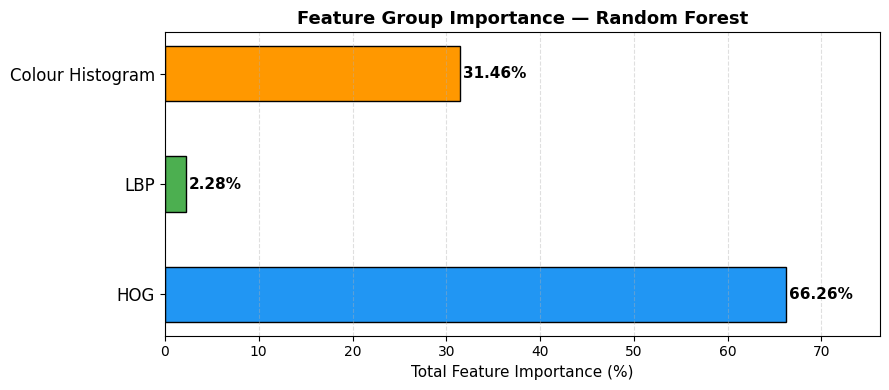

Snapshot saved: snapshot_13_feature_importance.png


In [80]:
# Plot feature group importances as a horizontal bar chart
group_colours = ["#2196F3", "#4CAF50", "#FF9800"]

figure, axis = plt.subplots(figsize=(9, 4))

bar_positions = range(len(group_names))
bars = axis.barh(
    bar_positions,
    [importance * 100 for importance in group_importances],
    color=group_colours,
    edgecolor="black",
    height=0.5
)

# Annotate bars
for bar_object, importance_value in zip(bars, group_importances):
    axis.text(
        bar_object.get_width() + 0.3,
        bar_object.get_y() + bar_object.get_height() / 2,
        f"{importance_value * 100:.2f}%",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

axis.set_yticks(bar_positions)
axis.set_yticklabels(group_names, fontsize=12)
axis.set_xlabel("Total Feature Importance (%)", fontsize=11)
axis.set_title(
    "Feature Group Importance — Random Forest",
    fontsize=13, fontweight="bold"
)
axis.set_xlim(0, max([i * 100 for i in group_importances]) + 10)
axis.grid(True, axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("snapshot_13_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Snapshot saved: snapshot_13_feature_importance.png")

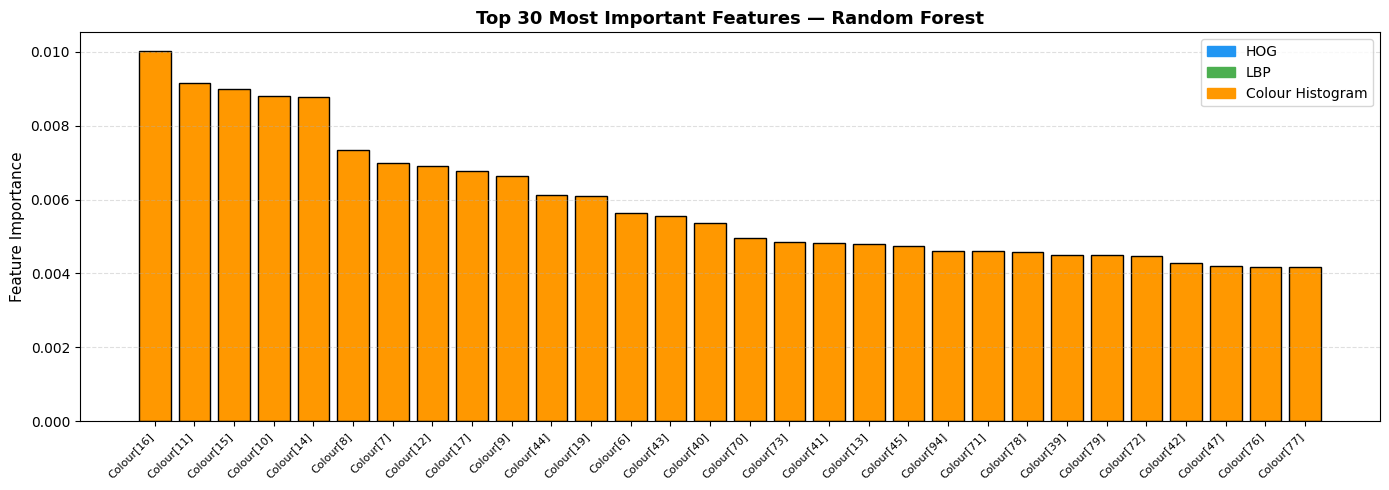

Snapshot saved: snapshot_14_top_features.png


In [81]:
# Plot the top 30 individual feature importances to understand which exact features matter most
number_of_top_features = 30

# Get the indices of the top N most important features
top_feature_indices    = np.argsort(feature_importances)[::-1][:number_of_top_features]
top_importance_values  = feature_importances[top_feature_indices]

# Label each index with its feature group name
def get_feature_group_label(feature_index, hog_end, lbp_end):
    if feature_index < hog_end:
        return f"HOG[{feature_index}]"
    elif feature_index < lbp_end:
        return f"LBP[{feature_index - hog_end}]"
    else:
        return f"Colour[{feature_index - lbp_end}]"


top_feature_labels = [
    get_feature_group_label(index, hog_end_index, lbp_end_index)
    for index in top_feature_indices
]

# Assign a colour to each bar based on its group
bar_colour_for_each_feature = []
for index in top_feature_indices:
    if index < hog_end_index:
        bar_colour_for_each_feature.append("#2196F3")   # Blue for HOG
    elif index < lbp_end_index:
        bar_colour_for_each_feature.append("#4CAF50")   # Green for LBP
    else:
        bar_colour_for_each_feature.append("#FF9800")   # Orange for Colour

figure, axis = plt.subplots(figsize=(14, 5))

axis.bar(
    range(number_of_top_features),
    top_importance_values,
    color=bar_colour_for_each_feature,
    edgecolor="black"
)

axis.set_xticks(range(number_of_top_features))
axis.set_xticklabels(top_feature_labels, rotation=45, ha="right", fontsize=8)
axis.set_ylabel("Feature Importance", fontsize=11)
axis.set_title(f"Top {number_of_top_features} Most Important Features — Random Forest", fontsize=13, fontweight="bold")

# Build a legend manually
legend_patches = [
    mpatches.Patch(color="#2196F3", label="HOG"),
    mpatches.Patch(color="#4CAF50", label="LBP"),
    mpatches.Patch(color="#FF9800", label="Colour Histogram"),
]
axis.legend(handles=legend_patches, fontsize=10)
axis.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("snapshot_14_top_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Snapshot saved: snapshot_14_top_features.png")

---
## Appendix D — Save & Load the Best Model

Once training is complete, we persist the best classifier and the fitted scaler to disk using `joblib`.  
This lets you load the model later without retraining.

In [82]:
import joblib
import datetime

# Identify the best classifier by cross-validation mean accuracy
best_classifier_name  = max(
    classifier_names,
    key=lambda name: cross_validation_results[name]["mean_accuracy"]
)
best_classifier_model = all_classifiers[best_classifier_name]

print(f"Best classifier selected: {best_classifier_name}")
print(f"CV mean accuracy         : {cross_validation_results[best_classifier_name]['mean_accuracy']:.2f}%")

# Save the model, scaler, and label encoder
saved_model_filename   = "best_classifier_model.joblib"
saved_scaler_filename  = "feature_scaler.joblib"
saved_encoder_filename = "label_encoder.joblib"

joblib.dump(best_classifier_model, saved_model_filename)
joblib.dump(feature_scaler,        saved_scaler_filename)
joblib.dump(label_encoder,         saved_encoder_filename)

print(f"\nModel saved to   : {saved_model_filename}")
print(f"Scaler saved to  : {saved_scaler_filename}")
print(f"Encoder saved to : {saved_encoder_filename}")
print(f"Saved at         : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Best classifier selected: Support Vector Machine
CV mean accuracy         : 88.97%

Model saved to   : best_classifier_model.joblib
Scaler saved to  : feature_scaler.joblib
Encoder saved to : label_encoder.joblib
Saved at         : 2026-05-21 18:04:54


In [83]:
# Reload and verify: load the saved files and run one prediction to confirm everything round-trips correctly
loaded_classifier = joblib.load(saved_model_filename)
loaded_scaler     = joblib.load(saved_scaler_filename)
loaded_encoder    = joblib.load(saved_encoder_filename)

print("Files reloaded successfully.")
print(f"Loaded classifier type : {type(loaded_classifier).__name__}")
print(f"Loaded encoder classes : {list(loaded_encoder.classes_)}")

# Quick smoke test: predict on the first test image using loaded objects
smoke_test_features = loaded_scaler.transform(testing_features[0].reshape(1, -1))
smoke_test_prediction = loaded_classifier.predict(smoke_test_features)[0]
smoke_test_label_name = loaded_encoder.inverse_transform([smoke_test_prediction])[0]
smoke_test_true_label = label_encoder.inverse_transform([testing_labels[0]])[0]

print(f"\nSmoke test — first test sample:")
print(f"  True label      : {smoke_test_true_label}")
print(f"  Predicted label : {smoke_test_label_name}")
print(f"  Correct         : {smoke_test_true_label == smoke_test_label_name}")

Files reloaded successfully.
Loaded classifier type : SVC
Loaded encoder classes : [np.str_('R10'), np.str_('R100'), np.str_('R20'), np.str_('R200'), np.str_('R50')]

Smoke test — first test sample:
  True label      : R20
  Predicted label : R20
  Correct         : True


---
## Appendix E — Colour Distribution per Denomination

South African bank notes have distinct dominant colours (e.g. R10 = green, R20 = brown, R50 = red).  
This cell plots the average colour histogram for each denomination, visually confirming why colour features are discriminative.

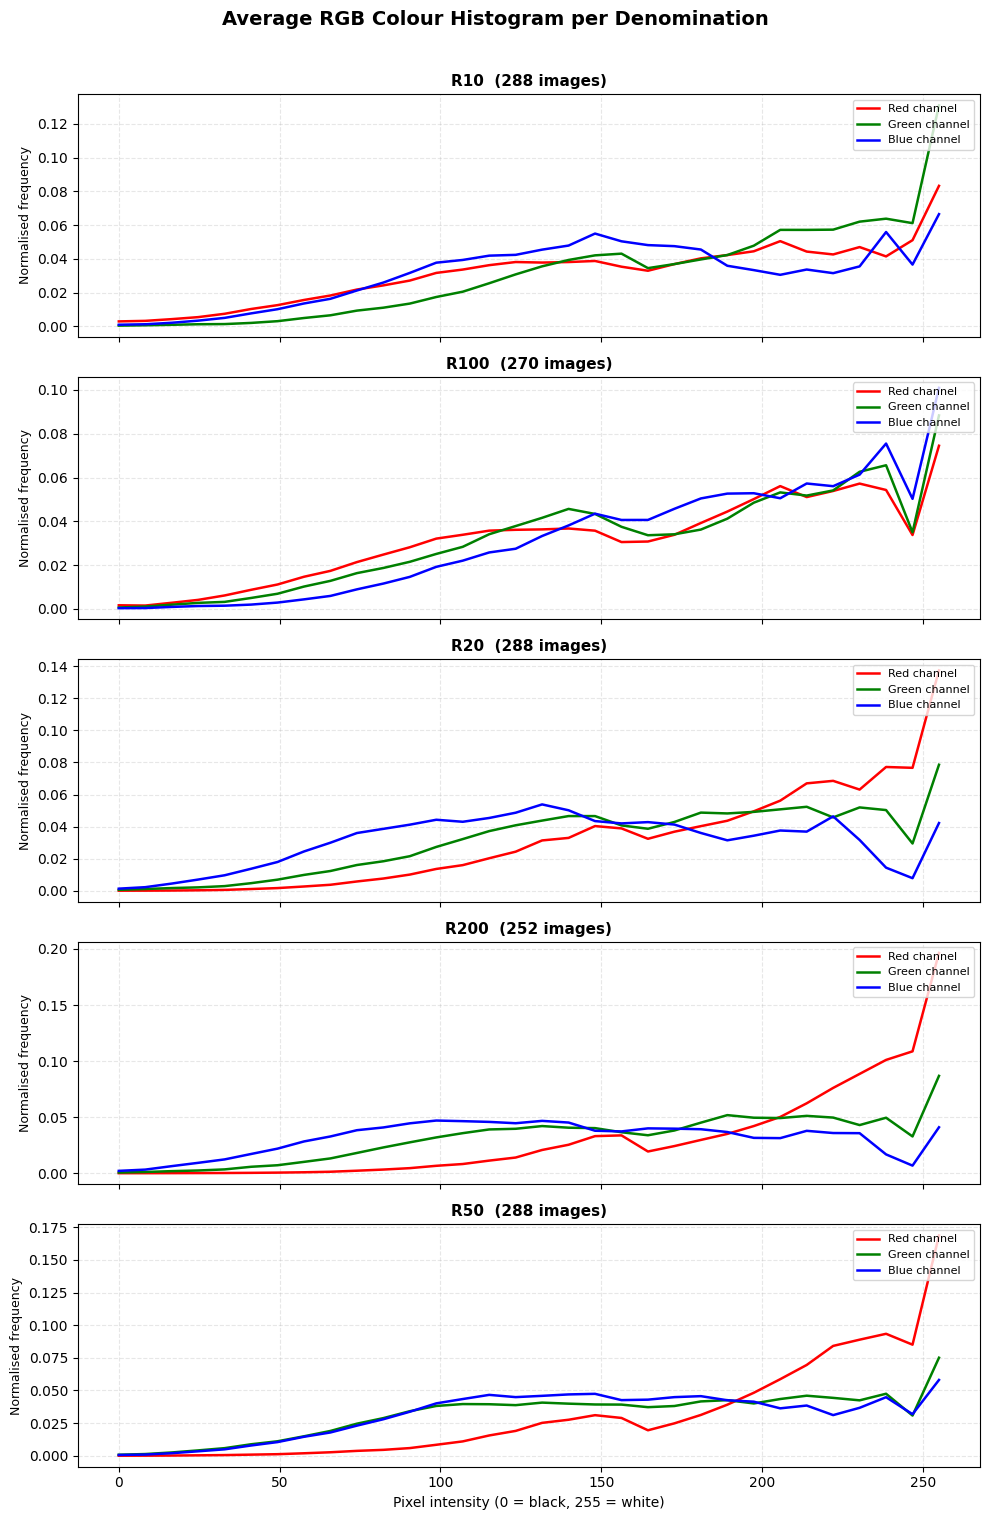

Snapshot saved: snapshot_15_colour_histograms.png


In [84]:
# Compute the average colour histogram per denomination
COLOUR_HISTOGRAM_BINS = 32
bin_centres = np.linspace(0, 255, COLOUR_HISTOGRAM_BINS)

figure, axes = plt.subplots(
    nrows=len(unique_denominations),
    ncols=1,
    figsize=(10, 3 * len(unique_denominations)),
    sharex=True
)
figure.suptitle(
    "Average RGB Colour Histogram per Denomination",
    fontsize=14, fontweight="bold", y=1.01
)

channel_display_colours = ["red", "green", "blue"]
channel_display_names   = ["Red channel", "Green channel", "Blue channel"]

for axis, denomination in zip(axes, unique_denominations):
    # Gather all images for this denomination
    denomination_image_list = [
        all_images[image_index]
        for image_index, label in enumerate(all_labels)
        if label == denomination
    ]

    for channel_index in range(3):
        # Compute the histogram for every image and average them
        channel_histograms = []
        for image in denomination_image_list:
            channel_pixels = image[:, :, channel_index]
            channel_hist, _bin_edges = np.histogram(
                channel_pixels.ravel(),
                bins=COLOUR_HISTOGRAM_BINS,
                range=(0, 256)
            )
            channel_hist_normalised = channel_hist.astype(float) / (channel_hist.sum() + 1e-7)
            channel_histograms.append(channel_hist_normalised)

        average_channel_histogram = np.mean(channel_histograms, axis=0)

        axis.plot(
            bin_centres,
            average_channel_histogram,
            color=channel_display_colours[channel_index],
            label=channel_display_names[channel_index],
            linewidth=1.8
        )

    axis.set_title(
        f"{denomination}  ({len(denomination_image_list)} images)",
        fontsize=11, fontweight="bold"
    )
    axis.set_ylabel("Normalised frequency", fontsize=9)
    axis.legend(fontsize=8, loc="upper right")
    axis.grid(True, linestyle="--", alpha=0.3)

axes[-1].set_xlabel("Pixel intensity (0 = black, 255 = white)", fontsize=10)

plt.tight_layout()
plt.savefig("snapshot_15_colour_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Snapshot saved: snapshot_15_colour_histograms.png")

---
## 10. Live Prediction — Upload

Run the cell below **after training is complete** (Section 5).  
It lets you **Upload** an image from your device

The system will classify it and show the predicted denomination with confidence.


Saving 100FO-1.jpg to 100FO-1.jpg
result: R100  |  confidence: 93.0%


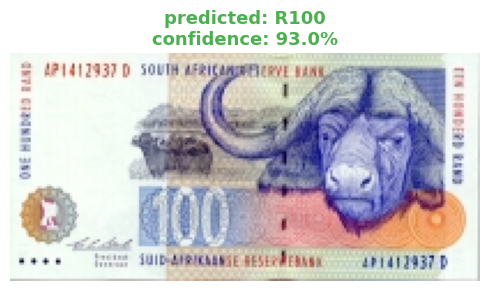

In [85]:
# live prediction — works on both colab and local jupyter
# on colab: uses the colab file upload widget
# locally: uses a file path input widget via ipywidgets
# run this cell after the classifiers have been trained (section 5)

import io
import sys
import ipywidgets as widgets
from IPython.display import display, clear_output

ON_COLAB = 'google.colab' in sys.modules or 'COLAB_GPU' in os.environ


def predict_from_array(rgb_image_array, classifier, scaler, encoder):
    # run the full pipeline on a numpy rgb image and return label + confidence
    resized      = cv2.resize(rgb_image_array, (IMAGE_WIDTH, IMAGE_HEIGHT))
    preprocessed = preprocess_single_image(resized)
    mask, _      = segment_with_otsu(preprocessed)
    segmented    = apply_mask_to_image(preprocessed, mask)
    features     = extract_combined_features(resized, segmented)
    features_sc  = scaler.transform(features.reshape(1, -1))

    pred_enc   = classifier.predict(features_sc)[0]
    proba      = classifier.predict_proba(features_sc)[0]
    label      = encoder.inverse_transform([pred_enc])[0]
    confidence = proba.max() * 100
    return label, confidence


def show_prediction_result(rgb_array, label, confidence):
    # display the image with the prediction overlaid
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(rgb_array)
    if confidence < 50:
        ax.set_title(
            f'uncertain — confidence too low ({confidence:.1f}%)\nimage may not be a bank note',
            fontsize=12, fontweight='bold', color='#F44336'
        )
        print(f'result: uncertain — confidence too low ({confidence:.1f}%)')
        print('image may not be a bank note, or the note is too obscured to classify')
    else:
        colour = '#4CAF50' if confidence >= 70 else '#FF9800'
        ax.set_title(
            f'predicted: {label}\nconfidence: {confidence:.1f}%',
            fontsize=13, fontweight='bold', color=colour
        )
        print(f'result: {label}  |  confidence: {confidence:.1f}%')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('snapshot_live_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()


best_clf_name  = max(results_summary, key=lambda n: results_summary[n]['test_accuracy'])
best_clf_model = all_classifiers[best_clf_name]
print(f'using best classifier: {best_clf_name}  '
      f'(test accuracy: {results_summary[best_clf_name]["test_accuracy"]*100:.1f}%)')
print()


if ON_COLAB:
    # colab upload widget
    from google.colab import files as colab_files

    print('click the button to upload a bank note image')
    btn_upload = widgets.Button(description='upload image', button_style='primary',
                                layout=widgets.Layout(width='180px'))
    display(btn_upload)

    def on_upload_clicked(_):
        clear_output(wait=True)
        uploaded = colab_files.upload()
        if not uploaded:
            print('no file selected')
            return
        filename  = next(iter(uploaded))
        img_array = np.frombuffer(uploaded[filename], dtype=np.uint8)
        bgr_image = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
        rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
        label, conf = predict_from_array(rgb_image, best_clf_model, feature_scaler, label_encoder)
        show_prediction_result(rgb_image, label, conf)

    btn_upload.on_click(on_upload_clicked)

else:
    # local jupyter — type a path or use a file chooser widget
    print('enter the path to a bank note image and click predict')
    path_input = widgets.Text(
        value='dataset/R50/example_front.jpg',
        description='image path:',
        layout=widgets.Layout(width='500px')
    )
    btn_predict = widgets.Button(description='predict', button_style='primary',
                                 layout=widgets.Layout(width='120px'))
    display(widgets.HBox([path_input, btn_predict]))

    def on_predict_clicked(_):
        clear_output(wait=True)
        image_path = path_input.value.strip()
        if not os.path.exists(image_path):
            print(f'file not found: {image_path}')
            return
        bgr_image = cv2.imread(image_path)
        rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
        label, conf = predict_from_array(rgb_image, best_clf_model, feature_scaler, label_encoder)
        show_prediction_result(rgb_image, label, conf)

    btn_predict.on_click(on_predict_clicked)
